# Computer Vision 1: Assignment 3

Task 1

Group Number 43

Marek Drwal

15.12.2025

## setup

In [142]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## defs

In [143]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    plt.show()

In [144]:
def show_img(img, pth='', comment=''):
    im = plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    return im

In [145]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [146]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [147]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [148]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## imgs

In [149]:
pth = 'coins.jpg'

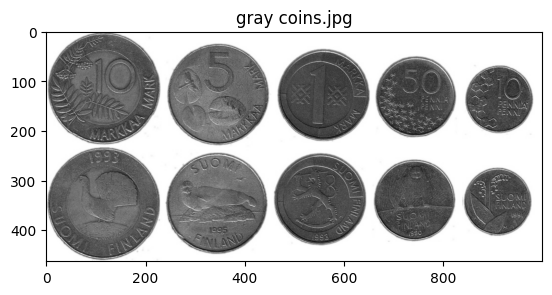

In [150]:
img = load_display_img(pth)

## radii

In [151]:
resolution = 0.12 ## mm/px

In [152]:
rs = [27.25, 24.5, 22.25, 19.7, 16.3]
rs = [r/2/resolution for r in rs]
rs

[113.54166666666667,
 102.08333333333334,
 92.70833333333334,
 82.08333333333333,
 67.91666666666667]

## Canny

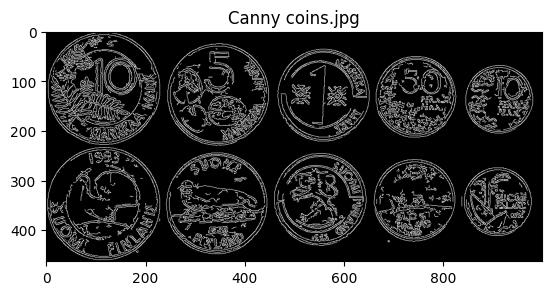

In [153]:
img_edge = ski.feature.canny(img)
show_img(img_edge, pth, 'Canny')

## Hough circle

In [154]:
h_circles = ski.transform.hough_circle(img_edge, rs)

In [155]:
h_circles.shape

(5, 463, 1000)

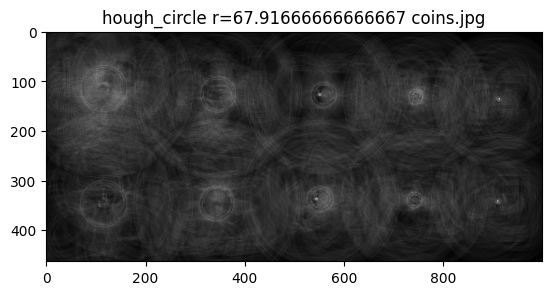

In [156]:
for im, r in zip(h_circles, rs):
    show_img(im, pth, f'hough_circle r={r}')

## Hough circle peaks

In [157]:
accums, cx, cy, radii = ski.transform.hough_circle_peaks(h_circles, rs, num_peaks=2, total_num_peaks=10, normalize=True)

In [158]:
accums

array([0.61197917, 0.55208333, 0.58898305, 0.78240741, 0.62689394,
       0.57007576, 0.68518519, 0.59075342, 0.54452055, 0.38559322])

In [159]:
cx

array([910, 914, 743, 116, 559, 552, 116, 343, 346, 743])

In [160]:
cy

array([341, 135, 340, 347, 129, 338, 115, 346, 127, 131])

In [161]:
radii

array([ 67.91666667,  67.91666667,  82.08333333, 113.54166667,
        92.70833333,  92.70833333, 113.54166667, 102.08333333,
       102.08333333,  82.08333333])

### vis

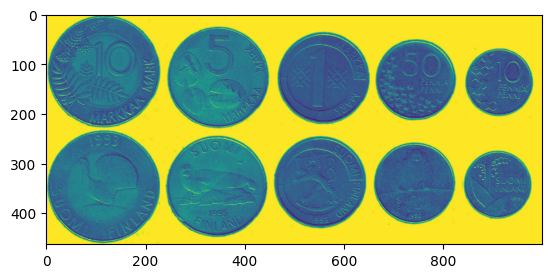

In [170]:
fig, ax = plt.subplots()
im = ax.imshow(img)
for x, y, r in zip(cx, cy, radii):
    patch = Circle((x,y), r, alpha=0, fill=False, transform=ax.transData)
    # im.set_clip_path(patch)
    ax.add_patch(patch)

plt.show()